# Notebook 2 — Create the Labels

**Goal**: build the late / on-time label from the delivery dates, check it makes
sense on a few real orders, then look at how balanced the two classes are.

**Reads**: artifacts/ml_table_orders.parquet (from notebook 1)
**Writes**: artifacts/labeled_table.parquet

In [11]:
import pandas as pd
from pathlib import Path

pd.set_option("display.max_columns", None)

ARTIFACTS_DIR = Path("artifacts")
df = pd.read_parquet(ARTIFACTS_DIR / "ml_table_orders.parquet")
df.shape

(99441, 31)

## Looking at the date columns first

The label needs order_delivered_customer_date (actual delivery) and
order_estimated_delivery_date (what Olist promised). 

In [12]:
df["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [13]:
df[["order_delivered_customer_date", "order_estimated_delivery_date"]].isna().sum()

order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [14]:
df[df["order_delivered_customer_date"].isna()]["order_status"].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

Makes sense, the missing delivery dates are basically all canceled, unavailable,
or still-in-progress orders. Can't say if those would've been late or not, so
they're getting dropped before building the label rather than guessing.

In [15]:
labeled = df[df["order_delivered_customer_date"].notna()].copy()
print(len(df), "->", len(labeled), "rows after dropping orders with no delivery date")

99441 -> 96476 rows after dropping orders with no delivery date


## Building the label

late if delivered after the estimated date, on time otherwise (delivering early
or exactly on the estimated date both count as on time).

In [16]:
labeled["order_delivered_customer_date"] = pd.to_datetime(labeled["order_delivered_customer_date"])
labeled["order_estimated_delivery_date"] = pd.to_datetime(labeled["order_estimated_delivery_date"])

labeled["is_late"] = (
    labeled["order_delivered_customer_date"] > labeled["order_estimated_delivery_date"]
).astype(int)

# how many days early/late, useful later for EDA
labeled["delivery_gap_days"] = (
    labeled["order_delivered_customer_date"] - labeled["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

labeled[["order_id", "order_delivered_customer_date", "order_estimated_delivery_date",
         "delivery_gap_days", "is_late"]].head()

,order_id,order_delivered_customer_date,order_estimated_delivery_date,delivery_gap_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-18,-7.107488,0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-13,-5.355729,0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-09-04,-17.245498,0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02 00:28:42,2017-12-15,-12.980069,0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16 18:17:02,2018-02-26,-9.238171,0


## Checking the label against real orders


In [17]:
check_cols = ["order_id", "order_delivered_customer_date", "order_estimated_delivery_date",
              "delivery_gap_days", "is_late"]

print("clearly late (gap > 5 days)")
display(labeled[labeled["delivery_gap_days"] > 5][check_cols].head(3))

print("\nclearly on time (delivered 5+ days early)")
display(labeled[labeled["delivery_gap_days"] < -5][check_cols].head(3))

print("\nright around the boundary (+/- 1 day)")
display(labeled[labeled["delivery_gap_days"].abs() <= 1][check_cols].head(5))

clearly late (gap > 5 days)


,order_id,order_delivered_customer_date,order_estimated_delivery_date,delivery_gap_days,is_late
20,203096f03d82e0dffbc41ebc2e2bcfb7,2017-10-09 22:23:46,2017-09-28,11.933171,1
25,fbf9ac61453ac646ce8ad9783d7d0af6,2018-03-21 22:03:54,2018-03-12,9.919375,1
41,6ea2f835b4556291ffdc53fa0b3b95e8,2017-12-28 18:59:23,2017-12-21,7.791238,1



clearly on time (delivered 5+ days early)


,order_id,order_delivered_customer_date,order_estimated_delivery_date,delivery_gap_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-18,-7.107488,0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-13,-5.355729,0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-09-04,-17.245498,0



right around the boundary (+/- 1 day)


,order_id,order_delivered_customer_date,order_estimated_delivery_date,delivery_gap_days,is_late
35,8563039e855156e48fccee4d611a3196,2018-03-20 00:59:25,2018-03-20,0.041262,1
78,6d25592267349b322799e2beb687871e,2018-08-29 12:40:53,2018-08-30,-0.471609,0
120,ee0c5c649e17808bc4a363d3a80ebf85,2018-02-20 15:25:04,2018-02-21,-0.357593,0
152,1d067305b599c1e0dceb3864056ea527,2018-03-09 21:52:36,2018-03-09,0.911528,1
226,c82a457d646f77c8f151e12a3e517ed2,2018-08-15 15:02:09,2018-08-15,0.626493,1


Checked a handful of rows by hand, the dates line up with is_late the way
they should: delivered_date after estimated_date gives is_late = 1, delivered
before or on the estimated date gives 0. The boundary cases (delivery_gap_days
close to 0) look correct too, no off-by-one issue with the > vs >= comparison.

## Class distribution

How many late vs on time, and whether this looks like a class imbalance problem.

In [18]:
counts = labeled["is_late"].value_counts()
pct = labeled["is_late"].value_counts(normalize=True) * 100

pd.DataFrame({"count": counts, "pct": pct.round(2)})

,count,pct
is_late,,
0,88649,91.89
1,7827,8.11


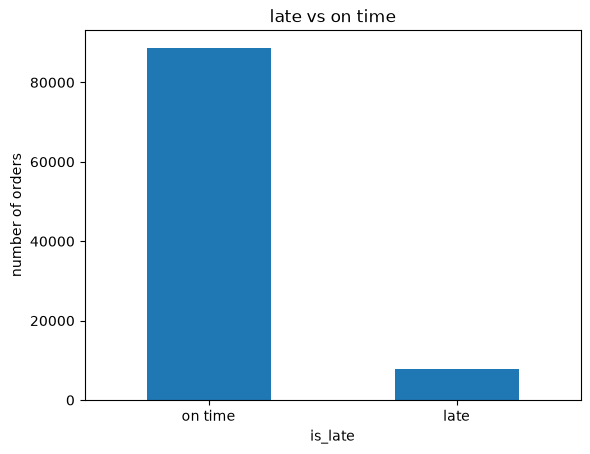

In [19]:
import matplotlib.pyplot as plt

labeled["is_late"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["on time", "late"], rotation=0)
plt.ylabel("number of orders")
plt.title("late vs on time")
plt.show()

Around 92% on time vs 8% late (exact numbers above). That's a real
imbalance, it's a full minority-class problem.
Means accuracy alone will look great even for a model that just always predicts
"on time", so this needs to be kept in mind for the metric choice in notebook 6.

## Saving the artifact

In [20]:
output_path = ARTIFACTS_DIR / "labeled_table.parquet"
labeled.to_parquet(output_path, index=False)

print(f"saved: {output_path}  ({labeled.shape[0]} rows, {labeled.shape[1]} columns)")

saved: artifacts/labeled_table.parquet  (96476 rows, 33 columns)


Dropped orders with no delivery date since there's nothing to label there,
built is_late by comparing delivered date to estimated date, spot-checked it
against real rows including boundary cases, and looked at the class split,
which is heavily imbalanced toward on time.